# Lab 2: Verlet integration for the Kepler problem

### This notebook should be used in conjunction with the Canvas Quizz: Computational Physics Lab 2. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: The Verlet method applied to the Kepler problem

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm

def kepler_analytic(vel,T):

    #-------------------------------------------------------------------------------
    # Calculate the analytic trajectory for the Kepler central force problem.
    # Assumes an initial position r = (1,0), v = (0,vel).
    #-------------------------------------------------------------------------------
    # INPUTS:
    # - vel: the initial speed.
    # - T: sets an upper limit for |theta| for the e > 1 case (plot up to the
    #        integration time).
    #-------------------------------------------------------------------------------

    # Calculate trajectory from analytic solution

    ecc = np.linalg.norm(vel)**2 - 1        # Eccentricity
    a = 1/(1 - ecc)                         # Semi-major axis

    if ecc < 1:

        theta = np.linspace(0, 2*np.pi, 50) # Equally spaced values from 0 to 2*pi
        b = a * np.sqrt(1 - ecc**2)
        xan = -a * ecc + a * np.cos(theta)
        yan =  b * np.sin(theta)

    else:

        b = a * np.sqrt(ecc**2 - 1)
        theta_max = np.arcsinh(np.linalg.norm(vel) * T/b) # Limit for range of theta
        theta = np.linspace( -theta_max, theta_max, 50)
        xan = - a * ecc + a * np.cosh(theta)
        yan =   b * np.sinh(theta)

    return xan, yan


## <span style="color:red">Q1</span>
### Run the code from the lecture (kepler_verlet.ipynb or kepler_dynamic.ipynb) for the initial non-dimensional velocities $(v_1 = 0.3, 0.9, 1, 1.2, 1.3, 1.5)$. For the first case you will need to reduce the time step from the default value ($\tau=0.05$, in non-dimensional units) to obtain a reasonably accurate integration. It may be helpful to consider changes in the time step through factors of 5 or 10. What are some valid indicators that your results are accurate?

In [45]:
def kepler_verlet(initial_pos, initial_vel, tau, T=4*np.pi):
    """
    Compute the solution of a kepler dynamics problem given an initial position, an initial velocity and a time step.

    Parameters
    ----------
    initial_pos : np.ndarray[float]
        An array of shape (2, 1) corresponding to the (non-dimensional) initial (x,y) coordinates. 
    initial_vel : np.ndarray[float]
        An array of shape (2, 1) corresponding to the (non-dimensional) initial (v_x,v_y) coordinates
    tau : float
        The (non-dimensional) time step used to evaluate the solution
    T : float = 4 * np.pi
        The total integration time
    """
    # Number of integration steps
    numSteps = int(np.ceil(T/tau))

    # Calculate trajectory from analytic solution.
    xan, yan = kepler_analytic(initial_vel, T)

    # Preallocate vectors for speed:
    time = tau*np.arange(numSteps+1)
    x = np.zeros(numSteps+1)
    y = np.zeros(numSteps+1)
    energy = np.zeros(numSteps+1)

    # Initial values:
    x[0], y[0] = initial_pos
    r = np.linalg.norm(initial_pos)
    speed = np.linalg.norm(initial_vel)
    accel = -initial_pos/r**3
    energy[0] = 0.5*speed**2 - 1/r

    #-------------------------------------------------------------------------------
    # Verlet method integration
    #-------------------------------------------------------------------------------
    pos = initial_pos
    vel = initial_vel
    
    prev = np.zeros_like(pos)
    next_pos = np.zeros_like(pos)

    for n in range(0, numSteps):

        # Take one step of the Verlet Method to update position:
        if n==0:
            # Get started with a midpoint method step
            next_pos = pos + tau*vel + 0.5*tau**2*accel
        else:
            # Normal Verlet update:
            next_pos = 2*pos - prev + tau**2*accel

        # Take one step of the Verlet Method to update velocity
        # (only required to compute energy, not the trajectory)
        if n==0:
            # Do a special (Velocity-Verlet) update for the very first step:
            r = np.linalg.norm(next_pos)
            accel_n2 = -next_pos/r**3
            vel = vel + tau/2*(accel + accel_n2)
        else: # n > 1
            # Do a Verlet update:
            vel = (next_pos - prev)/(2*tau)

        # Calculate speed, radial position, and acceleration after taking the step:
        speed = np.linalg.norm(vel)
        r = np.linalg.norm(next_pos)
        accel = -next_pos/r**3

        # Update energy after taking the step:
        energy[n+1] = 0.5*speed**2 - 1/r

        # Store position update:
        x[n+1] = next_pos[0]
        y[n+1] = next_pos[1]

        # Update 'prev' and 'pos' to calculate 'next_pos' in the following step:
        prev = pos
        pos = next_pos
    
    verlet = np.array([x, y]).T
    analytic = np.array([xan, yan]).T
    energy = np.array([time, energy]).T
    
    return verlet, analytic, energy

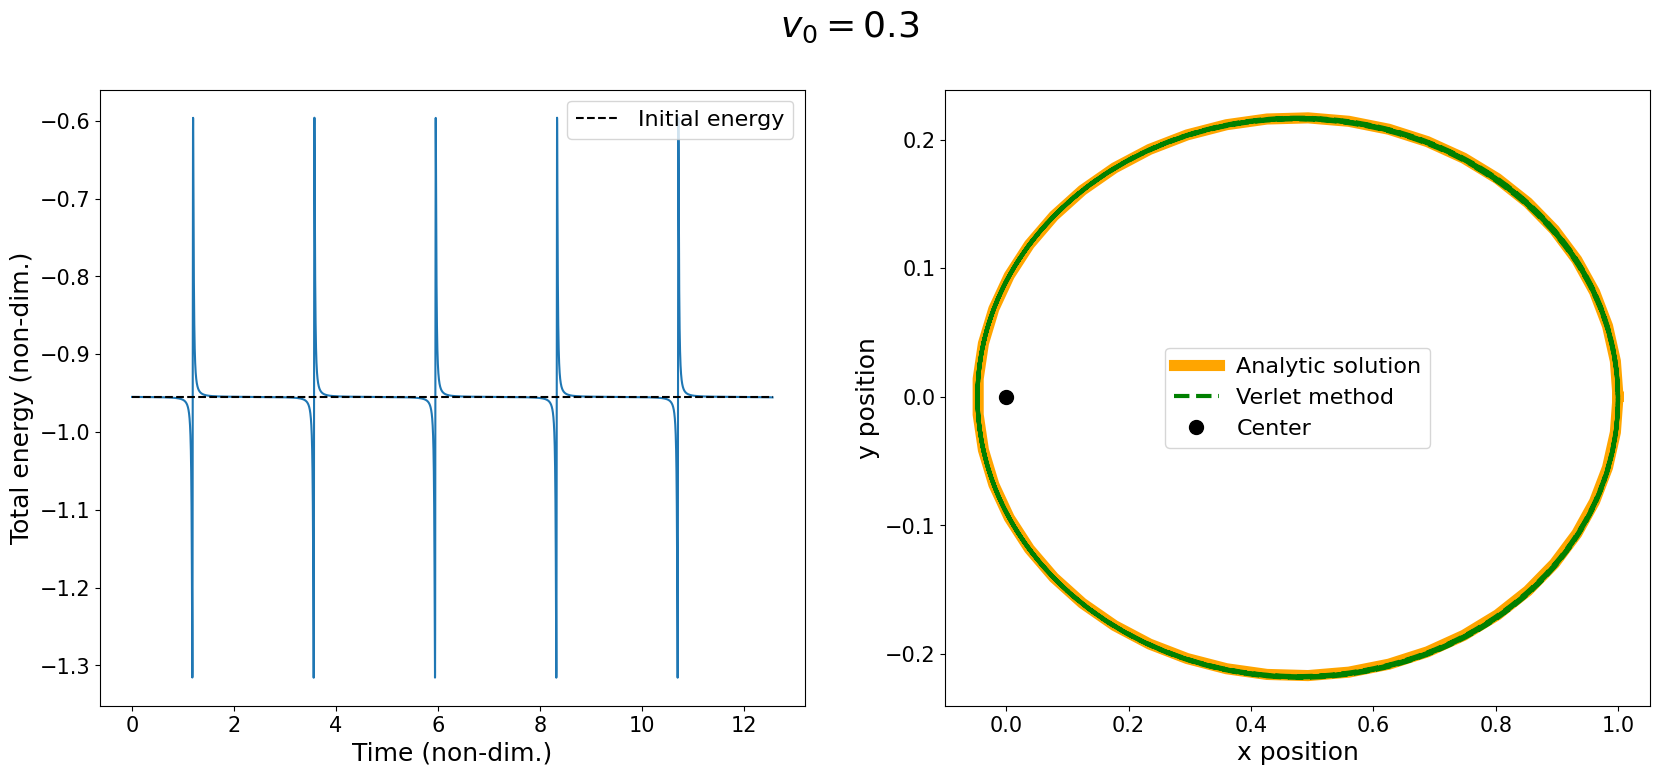

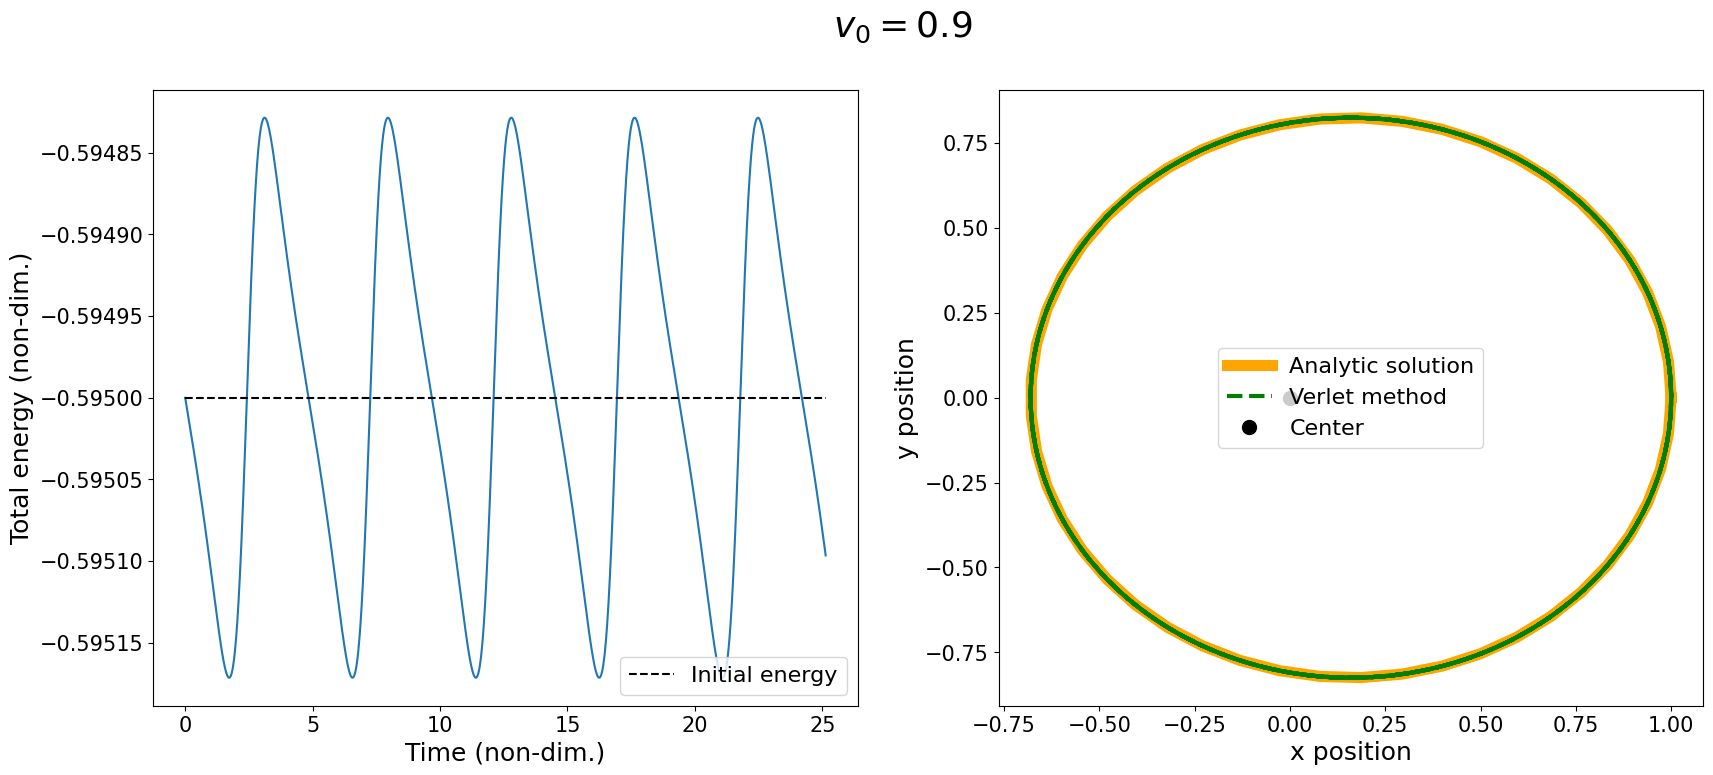

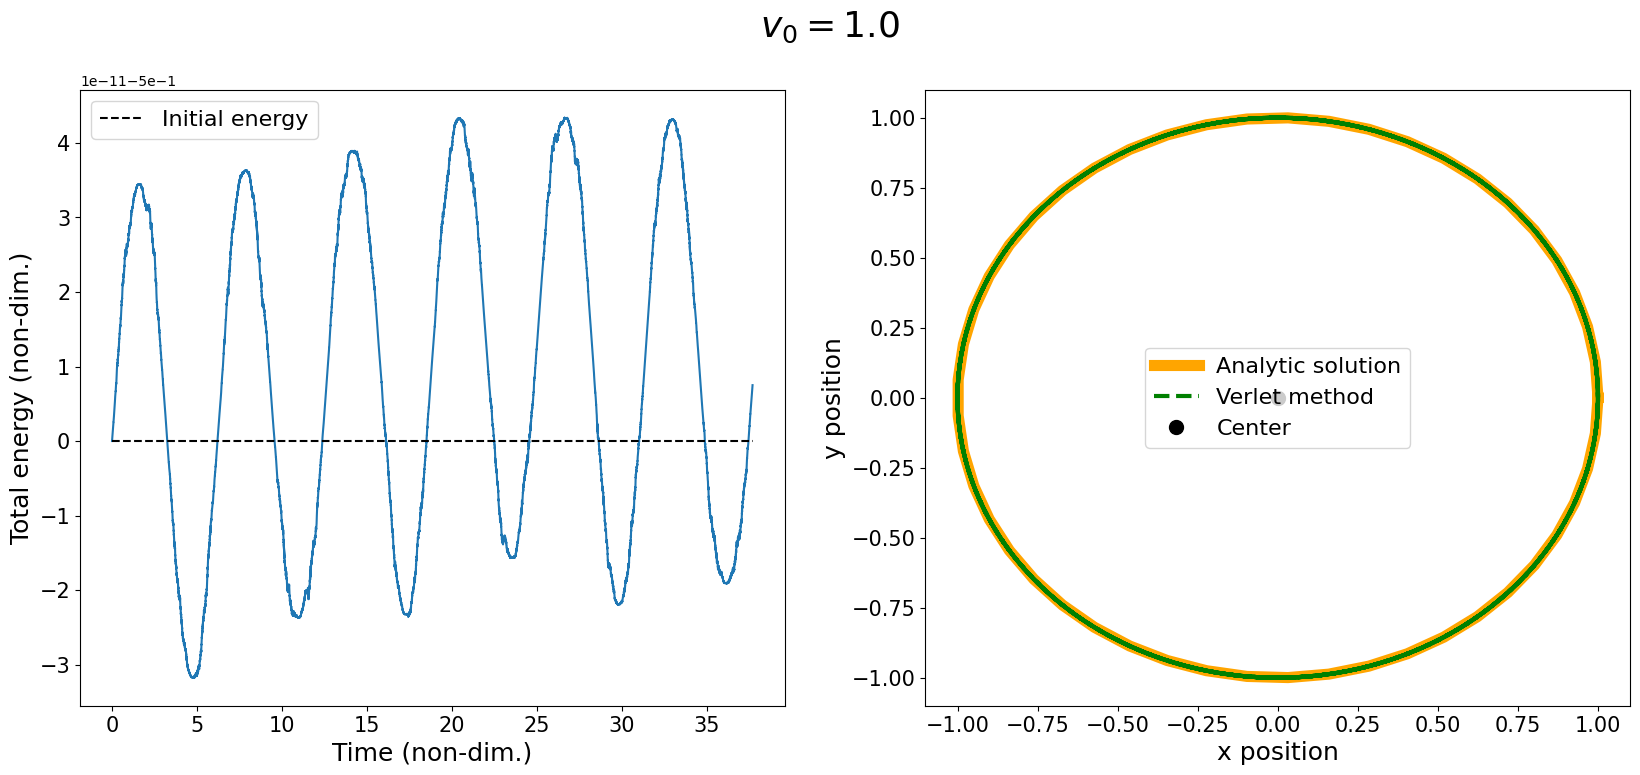

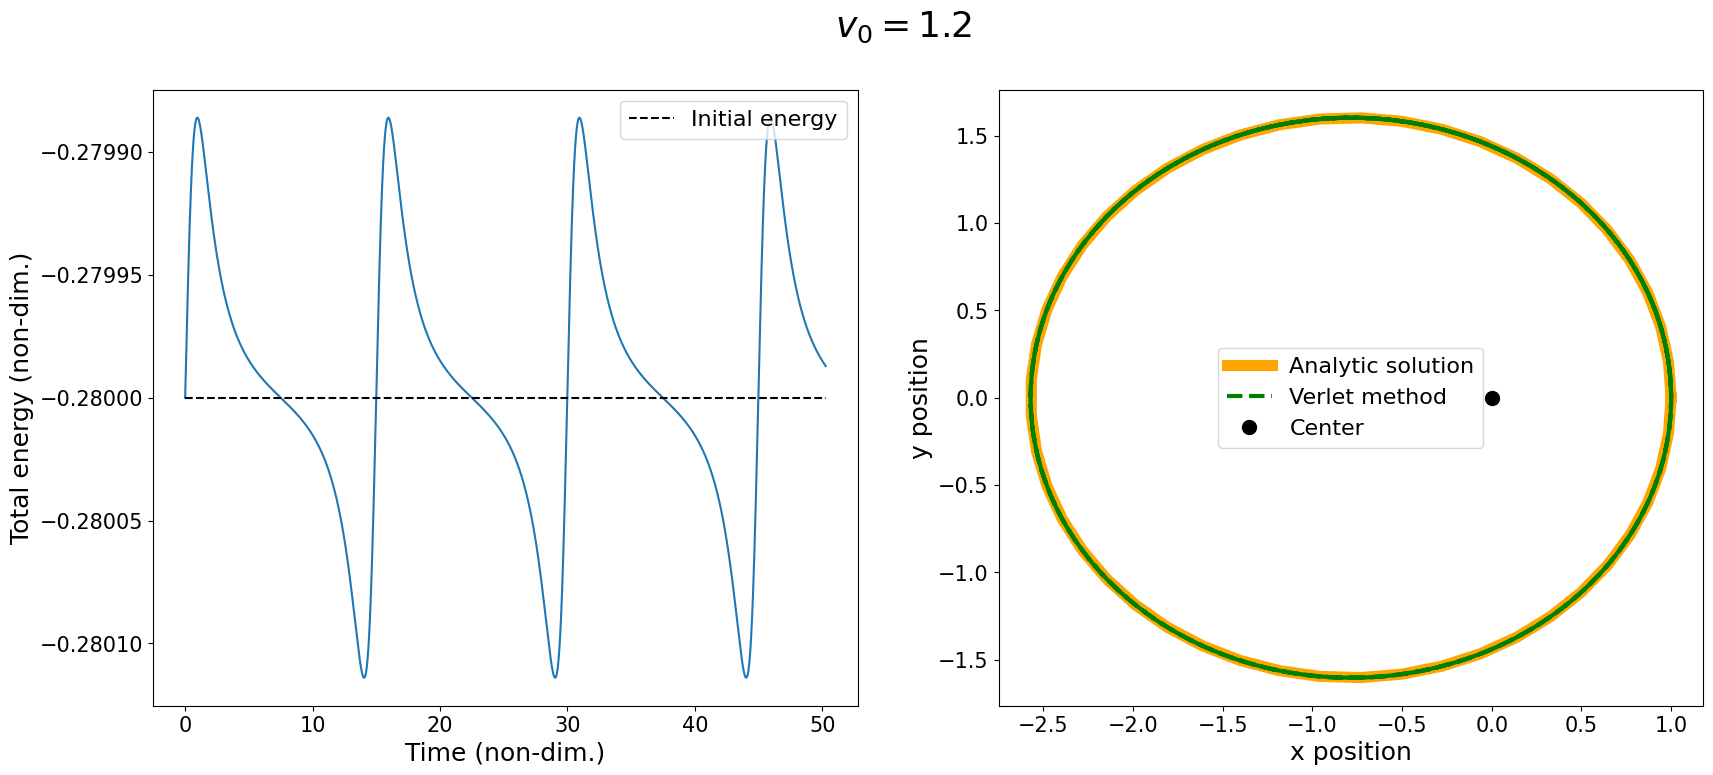

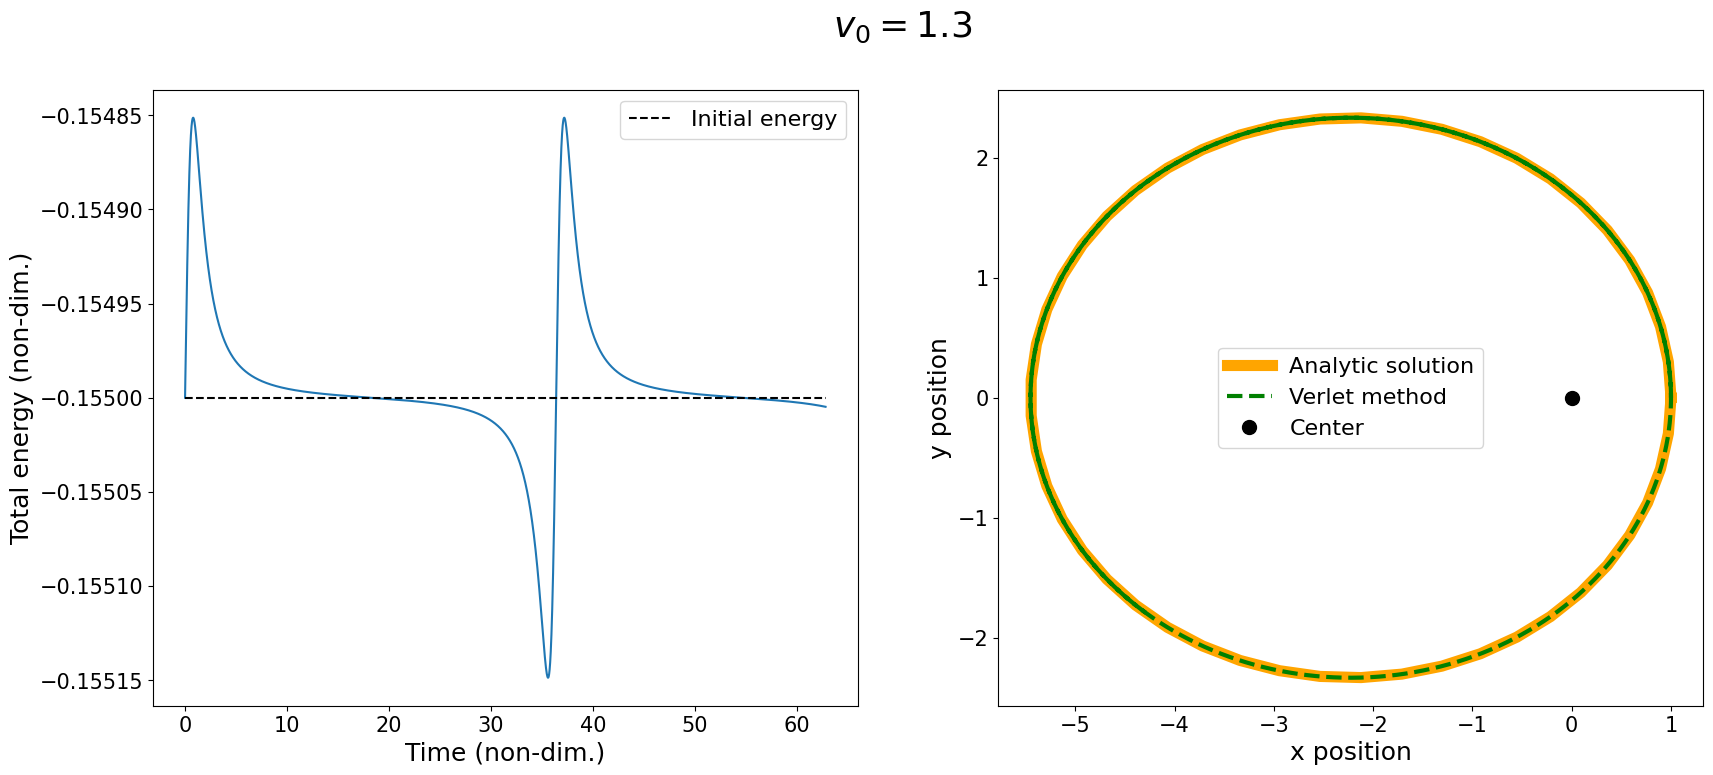

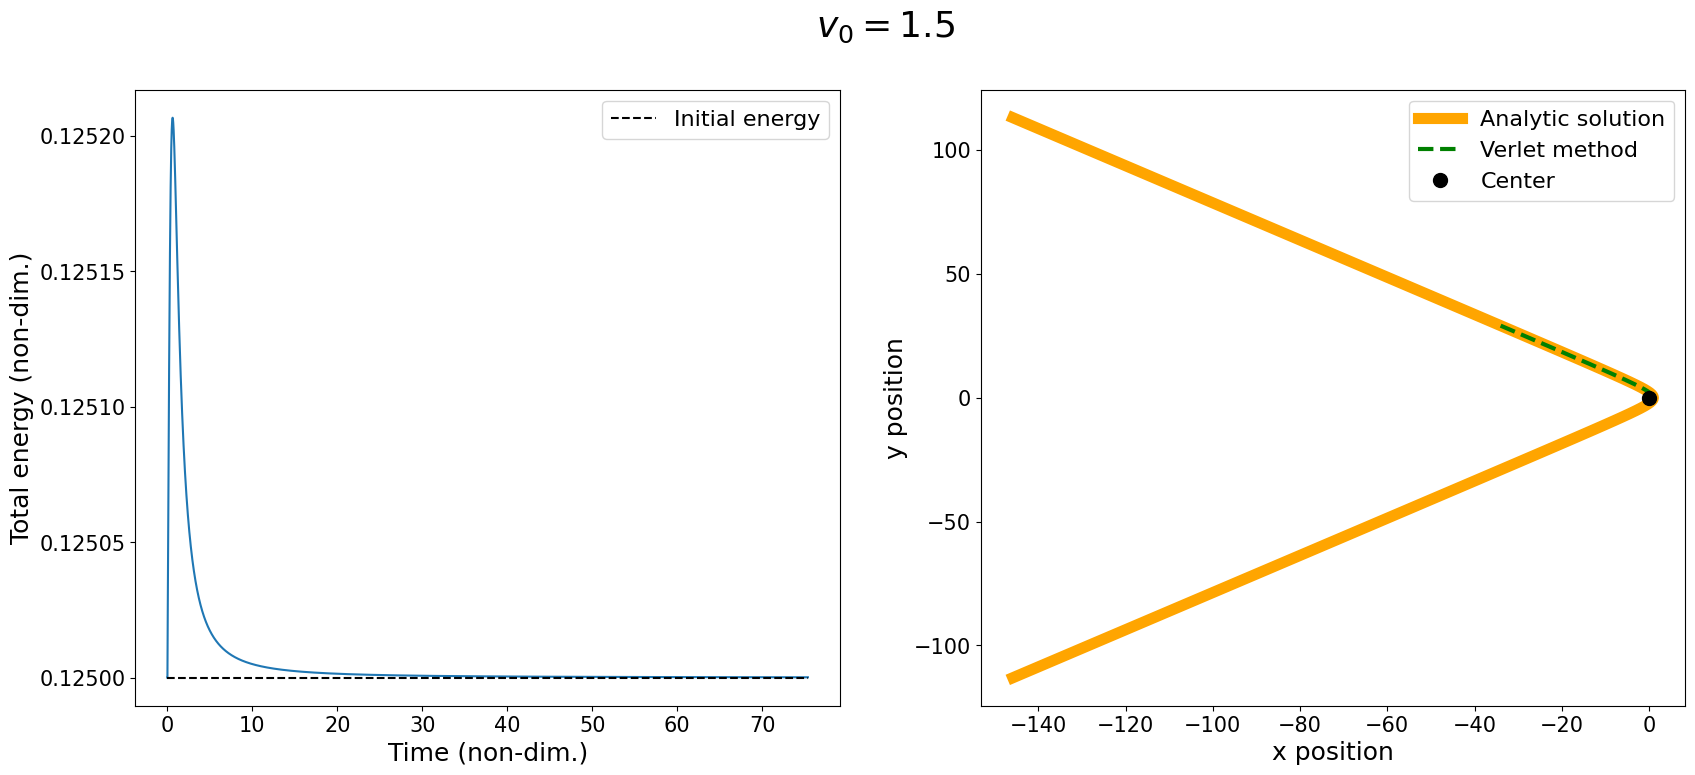

In [51]:
initial_pos = np.array([1, 0])
v_vec = np.array([0.3, 0.9, 1, 1.2, 1.3, 1.5])
tau = 0.0005

for i, v_y in enumerate(v_vec):
    verlet, analytic, energy = kepler_verlet(initial_pos, np.array([0, v_y]), tau, T=(i+1) * 4*np.pi)

    fig, ax = plt.subplots(1,2, figsize=(20,8))
    fig.suptitle(fr"$v_0 = {v_y}$", fontsize=26, fontweight="bold")
    ax[0].plot(*energy.T)
    ax[0].plot([min(energy[:, 0]),max(energy[:, 0])],np.ones(2)*energy[0, 1], '--k', label='Initial energy') # Initial energy line

    ax[0].tick_params(labelsize=15)
    ax[0].set_xlabel("Time (non-dim.)", fontsize=18);
    ax[0].set_ylabel("Total energy (non-dim.)", fontsize=18)
    ax[0].legend(fontsize=16);

    # Right plot 

    ax[1].plot(*analytic.T, color='orange', lw=8, label="Analytic solution")
    ax[1].plot(*verlet.T, '--g', lw=3, label="Verlet method")
    ax[1].plot(0,0, 'ko', markersize = 10, label="Center")

    ax[1].tick_params(labelsize=15)
    # ax[1].set(xlim=[-1.5,1.5], ylim=[-1.5,1.5])
    ax[1].set_xlabel("x position", fontsize=18)
    ax[1].set_ylabel("y position", fontsize=18)
    ax[1].legend(fontsize=16);

*Your notes:*
For larger tau ($\bar\tau = 0.5$) we see large variations $O(0.1 \to 1)$ in energy for all initial velocities, many systems do not conserve energy and the first system for $\bar v_0 = 0.3$ has a weird effect where the smaller mass is drawn into the larger mass and is slingshotted away from the system. In this case the enrgy of the system seems to increase.

For medium tau ($\bar\tau = 0.05$) we see smaller variations $O(10^{-5}, 0.1)$ from initial conditions in energy for $\bar v_0 = 0.9, 1$ respectively and the systems for $v_0 = 1.3, 1.5$ return very close to inital energy after the smaller mass is shot into space. The system for $v_0 = 0.3$ almost starts orbiting the larger mass but is eventually shot off way into space with considerably more energy than it had initially.

For small tau ($\bar\tau = 0.005$) we see smaller variations $O(10^{-5}, 0.1)$ from initial conditions in energy for $\bar v_0 = 0.9, 1$ respectively and the systems for $v_0 = 1.2, 1.3, 1.5$ return even closer to inital energy after the smaller mass is shot into space. The system for $v_0 = 0.3$ is beginning to show periodic solution by orbiting the larger mass.

## <span style="color:red">Q2</span>
### Obtain accurate orbits for the cases  \($v_1$=0.3, 0.9, 1, 1.2, 1.3, 1.5\).




Match each case with the most accurate description of its orbit.




Note that the 'near' focus refers to being nearer the initial condition and a 'far' focus refers to one farther from the initial condition.

*Your notes:*

|initial velocity | type of orbit |
|---|---|
|$v_0 = 0.3$ | Ellipse with sun at far focus point | 
| $v_0 = 0.9$ | Ellipse with sun at far focus point|
| $v_0 = 1.0$ | Circle with sun at center|
| $v_0 = 1.2$ | Ellipse with sun at near focus point|
| $v_0 = 1.3$ | Ellipse with sun at near focus point|
| $v_0 = 1.5$ | hyperbolic trajectory|

## <span style="color:red">Q3</span>
### Without changing the numerical integration, modify Verlet method code to store the speed and the distance from the Sun at each time step as a vector, in the same way that the code stores the energy at each time step.


For the initial conditions `r_1=[1,0]`, and `v_1=[0,0.7]`
together with the total integration time `T=10` and time step `tau=0.01`, plot the speed and distance as a function of time.


Notice the distance from the sun at which the speed is a maximum/minimum.


Produce a single plot with your results, save it as an image, and upload it below.

*Your notes:*

In [61]:
def kepler_verlet(initial_pos, initial_vel, tau, T=4*np.pi):
    """
    Compute the solution of a kepler dynamics problem given an initial position, an initial velocity and a time step.

    Parameters
    ----------
    initial_pos : np.ndarray[float]
        An array of shape (2, 1) corresponding to the (non-dimensional) initial (x,y) coordinates. 
    initial_vel : np.ndarray[float]
        An array of shape (2, 1) corresponding to the (non-dimensional) initial (v_x,v_y) coordinates
    tau : float
        The (non-dimensional) time step used to evaluate the solution
    T : float = 4 * np.pi
        The total integration time
    """
    # Number of integration steps
    numSteps = int(np.ceil(T/tau))

    # Calculate trajectory from analytic solution.
    xan, yan = kepler_analytic(initial_vel, T)

    # Preallocate vectors for speed:
    time = tau*np.arange(numSteps+1)
    x = np.zeros(numSteps+1)
    y = np.zeros(numSteps+1)
    energy = np.zeros(numSteps+1)
    r_from_sun = np.zeros(numSteps+1)
    speed_vals = np.zeros(numSteps+1)

    # Initial values:
    x[0], y[0] = initial_pos
    r = np.linalg.norm(initial_pos)
    speed = np.linalg.norm(initial_vel)
    accel = -initial_pos/r**3
    energy[0] = 0.5*speed**2 - 1/r

    #-------------------------------------------------------------------------------
    # Verlet method integration
    #-------------------------------------------------------------------------------
    pos = initial_pos
    vel = initial_vel
    
    prev = np.zeros_like(pos)
    next_pos = np.zeros_like(pos)

    for n in range(0, numSteps):
        r_from_sun[n] = np.linalg.norm(pos)
        speed_vals[n] = np.linalg.norm(vel)

        # Take one step of the Verlet Method to update position:
        if n==0:
            # Get started with a midpoint method step
            next_pos = pos + tau*vel + 0.5*tau**2*accel
        else:
            # Normal Verlet update:
            next_pos = 2*pos - prev + tau**2*accel

        # Take one step of the Verlet Method to update velocity
        # (only required to compute energy, not the trajectory)
        if n==0:
            # Do a special (Velocity-Verlet) update for the very first step:
            r = np.linalg.norm(next_pos)
            accel_n2 = -next_pos/r**3
            vel = vel + tau/2*(accel + accel_n2)
        else: # n > 1
            # Do a Verlet update:
            vel = (next_pos - prev)/(2*tau)

        # Calculate speed, radial position, and acceleration after taking the step:
        speed = np.linalg.norm(vel)
        r = np.linalg.norm(next_pos)
        accel = -next_pos/r**3

        # Update energy after taking the step:
        energy[n+1] = 0.5*speed**2 - 1/r

        # Store position update:
        x[n+1] = next_pos[0]
        y[n+1] = next_pos[1]

        # Update 'prev' and 'pos' to calculate 'next_pos' in the following step:
        prev = pos
        pos = next_pos
    
    r_from_sun[-1] = np.linalg.norm(pos)
    speed_vals[-1] = np.linalg.norm(vel)

    verlet = np.array([x, y]).T
    analytic = np.array([xan, yan]).T
    
    return verlet, analytic, time, energy, r_from_sun, speed_vals

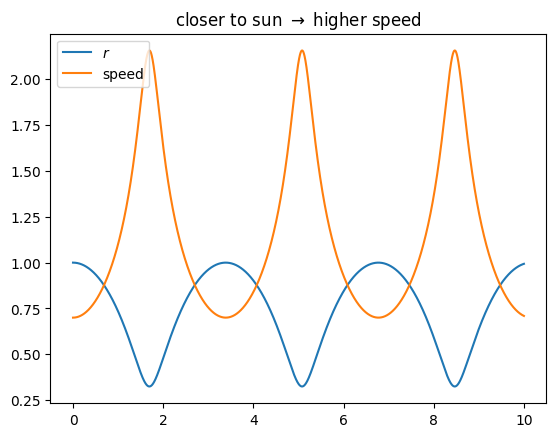

In [74]:
initial_pos = np.array([1, 0])
v_y = 0.7
tau = 0.001


verlet, analytic, time, energy, r_from_sun, speed_vals = kepler_verlet(initial_pos, np.array([0, v_y]), tau, T=10)

plt.plot(time, r_from_sun, label=r"$r$")
plt.plot(time, speed_vals, label="speed")
plt.legend()
plt.title(r"closer to sun $\to$ higher speed")
plt.savefig("q3.png")
plt.show()

## <span style="color:red">Q4</span>
### Use the min and max functions to compute the ratio of the maximum to the minimum speed, and the ratio of the maximum to the minimum distance, for your results for Q3 above.


You should find that 
$$\frac{v_{\rm max}}{v_{\rm min}}=\frac{r_{\rm max}}{r_{\rm min}}.$$

If you do not find this, there is an error in your code.

What is the ratio 
$$R=\frac{v_{\rm max}}{v_{\rm min}}=\frac{r_{\rm max}}{r_{\rm min}}?$$


*Your notes:*

In [76]:
# Include your code here #
min_r = np.min(r_from_sun)
max_r = np.max(r_from_sun)
min_speed = np.min(speed_vals)
max_speed = np.max(speed_vals)

print(max_r / min_r)
print(max_speed / min_speed)

3.081617506203045
3.0816175947923483


## <span style="color:red">Q5</span>
### The angular momentum of the planet or comet is ${\bf L}={\bf r}\times m{\bf v}$. This quantity is constant during the motion because the force on the planet or comet is radially inwards, which means the torque, $\tau = {\bf r} \times {\bf F} = 0$.
 
The magnitude of the angular momentum is $L=mvr\sin\phi,$ where $\phi$ is the angle between ${\bf v}$ and ${\bf r}$.
 
By considering the angular momentum at perihelion and aphelion (closest and furthest approach from the Sun), prove that
$$v_{\rm max}/v_{\rm min}=r_{\rm max}/r_{\rm min}.$$ 
 
**Write a few line proof.**

*Your notes:*

# <span style="color:k">Part II: Halley's Comet</span>

## <span style="color:red">Q6</span>
### Using the analytic solution to the Kepler problem (see the Appendix to the lecture notes from this week), and assuming non-dimensional initial conditions ${\bf r}_1=(1,0)$, ${\bf v}_1=(0,v_1)$, determine the value of $v_1$ corresponding to an orbit with $a=17.834$.  

Hint: As in the lecture notes, for an elliptical orbit we have eccentricity $e = v_1^2 - 1$ and semi-major axis $a = \frac{1}{1-e}$.

Note: Give your answer for $v_1$ to at least two decimal places below.

Hint: It will be helpful to retain your calculation for $v_1$ to full precision to obtain accurate answers for the subsequent calculations (below).

*Your notes:*

## <span style="color:red">Q7</span>
### Modify the code Verlet method code to integrate the equations of motion for the initial conditions in 6. Choose a suitable value of $\tau$ for an accurate numerical solution, and a value of the total integration time $T$ which encompasses one period. (*Note*: You will require a large number of integration steps.)
 
Estimate the non-dimensional period $P$ of the motion based on your numerical results. 
 
*Suggestion:* One way to estimate the period is from the plot of total energy versus time. From the Matlab figure, you can identify the period based on the dip in estimated energy associated with closest approach to the Sun (perihelion). 
 
**Write your answer as a number (to at least three significant figures).**

*Your notes:*

## <span style="color:red">Q8</span>
### Convert the non-dimensional period obtained in Question 7, above, into years. How does your result compare with the experimental estimate of between 75-76 years?

You should use the values of the constants $1~\text{au}=1.5\times 10^{11}$ m, $G = 6.67\times 10^{-11}$ kg$^{-1}$m$^3$s$^{-2}$, $M_{\odot}=1.99\times 10^{30}$ kg.

Give a brief comment.

*Your notes:*